# Import librerie e creazione DF

In [2]:
import pandas as pd
import numpy as np
import optuna
import time
import threading
import psutil
import os
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [2]:
df = pd.read_csv('dati_tesi_finali_addestramento.csv', sep=',', encoding='UTF-8')

# Preparazione dataset

1. Gestione colonne di data

In [3]:
df["data_record_start_time"] = pd.to_datetime(df["data_record_start_time"])
df['data_record_end_time'] = pd.to_datetime(df['data_record_end_time'])

2. Creazione funzione di analisi tempo, RAM e CPU

In [ ]:
_process      = psutil.Process(os.getpid())
LOGICAL_CORES = 8   # 4 core fisici x 2 hyperthreading

class ResourceMonitor:
    """
    Campiona RAM (RSS) e tempo wall-clock durante il fit.
    La CPU viene misurata una volta dopo il fit su un intervallo
    reale di 1s e normalizzata per i logical processor (8),
    così il valore è confrontabile con il Task Manager.
    """

    def start(self):
        self._ram_samples = []
        self._cpu_samples = []
        self._t_start     = time.time()
        self._stop        = threading.Event()
        # prima chiamata a cpu_percent per inizializzare il contatore
        _process.cpu_percent()

        def _sampler():
            while not self._stop.is_set():
                self._ram_samples.append(
                    _process.memory_info().rss / 1024 ** 2
                )
                self._cpu_samples.append(
                    _process.cpu_percent() / LOGICAL_CORES
                )
                time.sleep(0.5)

        self._thread = threading.Thread(target=_sampler, daemon=True)
        self._thread.start()
        return self

    def stop(self):
        self._stop.set()
        self._thread.join()
        self.elapsed_s    = time.time() - self._t_start
        self.ram_mean_mb  = float(np.mean(self._ram_samples))
        self.ram_peak_mb  = float(np.max(self._ram_samples))
        self.ram_delta_mb = self.ram_peak_mb - self._ram_samples[0]
        self.cpu_pct      = float(np.mean(self._cpu_samples)) if self._cpu_samples else 0.0
        return self

    def report(self):
        print(f"  Tempo di addestramento + fine tuning          : {self.elapsed_s:.1f}s")
        print(f"  RAM media utilizzata                          : {self.ram_mean_mb:.0f} MB")
        print(f"  CPU utilizzata                                : {self.cpu_pct:.1f}%")

3. Fold dataset

In [ ]:
# Fold 1 (test invernale)   — Train: gen–set | Val: ott | Test: nov–dic
# Fold 2 (test estivo)      — Train: gen–apr | Val: mag | Test: giu–lug
# Fold 3 (test primaverile) — Train: gen–feb | Val: mar | Test: apr–mag

4. Feature Engineering

In [ ]:
def add_time_features(df):
    t = df["data_record_start_time"]
    df = df.copy()
    df["hour"]       = t.dt.hour
    df["dayofweek"]  = t.dt.dayofweek
    df["day"]        = t.dt.day
    df["month"]      = t.dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["hour_sin"]   = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"]   = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"]    = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"]    = np.cos(2 * np.pi * df["dayofweek"] / 7)
    return df

def add_lag_features(df_train, df_val, df_test):
    full = pd.concat([df_train, df_val, df_test]).sort_values(
        ["station_id", "data_record_start_time"]
    )
    g = ["station_id"]
    full["lag_1h"]       = full.groupby(g)["data_record_value"].shift(1)
    full["lag_2h"]       = full.groupby(g)["data_record_value"].shift(2)
    full["lag_24h"]      = full.groupby(g)["data_record_value"].shift(24)
    full["roll_mean_6h"] = (
        full.groupby(g)["data_record_value"]
            .transform(lambda x: x.shift(1).rolling(6, min_periods=1).mean())
    )
    return (full.loc[df_train.index],
            full.loc[df_val.index],
            full.loc[df_test.index])

FEATURES = [
    "station_id", "station_lat", "station_lon", "station_altitude",
    "region_enc",
    "temperature_2m (°C)", "relative_humidity_2m (%)",
    "precipitation (mm)", "wind_speed_10m (km/h)", "wind_direction_10m (°)",
    "hour", "dayofweek", "day", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "lag_1h", "lag_2h", "lag_24h", "roll_mean_6h",
]

le_region = LabelEncoder()
df["region_enc"] = le_region.fit_transform(df["region_name"].astype(str))
df = add_time_features(df)

# Addestramento XGBoost

In [ ]:
FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

N_TRIALS = 30

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # ── Optuna ───────────────────────────
        def objective(trial):
            params = {
                "n_estimators":     trial.suggest_int("n_estimators", 200, 1000),
                "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth":        trial.suggest_int("max_depth", 3, 8),
                "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": 42, "n_jobs": -1,
                "eval_metric": "rmse", "early_stopping_rounds": 30,
            }
            m = XGBRegressor(**params)
            m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
            return mean_squared_error(y_val, m.predict(X_val)) ** 0.5

        # ── Optuna + fit finale con monitoraggio ──
        monitor = ResourceMonitor().start()

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")

        model = XGBRegressor(
            **best,
            random_state=42, n_jobs=-1,
            eval_metric="rmse", early_stopping_rounds=50,
        )

        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        monitor.stop()

        print(f"  Best iteration: {model.best_iteration}")
        monitor.report()

        # ── Metriche ─────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_train, y_train)
        pred_v, true_v = metrics("Val",  X_val,  y_val)
        pred_t, true_t = metrics("Test", X_test, y_test)

        fi   = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")

        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":           fold["name"],
            "pollutant":      pollutant,
            "n_train":        len(X_train),
            "n_val":          len(X_val),
            "n_test":         len(X_test),
            "best_iter":      model.best_iteration,
            "test_mae":       mean_absolute_error(true_t, pred_t),
            "test_rmse":      np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":        r2_score(true_t, pred_t),
            "top3_feat":      top3,
            "train_time_s":   round(monitor.elapsed_s, 1),
            "ram_mean_mb":    round(monitor.ram_mean_mb, 1),
            "cpu_pct":        round(monitor.cpu_pct, 1),
            "best_params":    str(best),
        })

# ─────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold","pollutant","n_train","n_test",
               "test_mae","test_rmse","test_r2",
               "train_time_s","ram_mean_mb","cpu_pct"]].to_string(index=False))

summary.to_csv("XGBoost_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'n_estimators': 431, 'learning_rate': 0.08793641207623464, 'max_depth': 8, 'subsample': 0.9401253487586924, 'colsample_bytree': 0.6021796128219522, 'min_child_weight': 8, 'reg_alpha': 0.007865137330185708, 'reg_lambda': 0.019097354910891203}
  Best iteration: 87
  Tempo di addestramento + fine tuning          : 453.6s
  RAM media utilizzata                          : 582 MB
  CPU utilizzata                                : 65.1%
  Train  → MAE=49.915  RMSE=97.192  R²=0.8978
  Val    → MAE=66.802  RMSE=124.305  R²=0.8067
  Test   → MAE=123.014  RMSE=210.720  R²=0.6952
  Top f

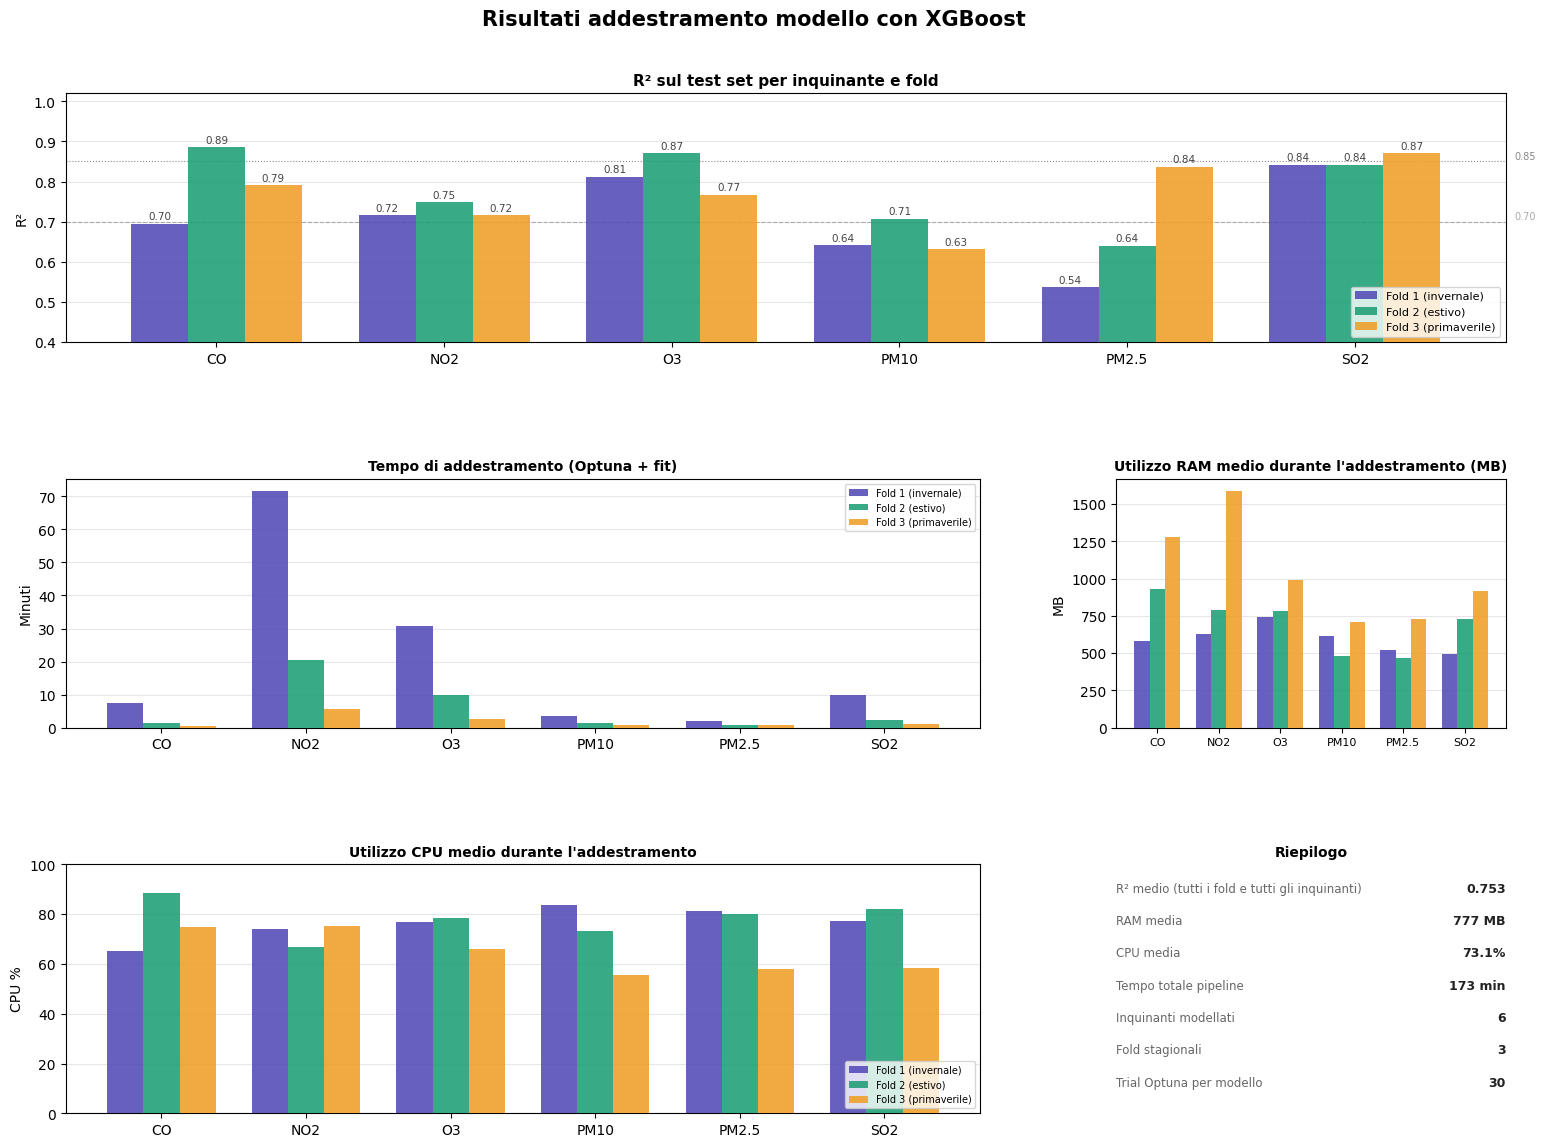

In [2]:
# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("XGBoost_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con XGBoost", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0] / 60
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Minuti")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("XGBoost_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento LightGBM

In [ ]:
FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

N_TRIALS = 30
 
all_summary = []
all_results = []
 
for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")
 
    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]
 
    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")
 
        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])
 
        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]
 
        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue
 
        train, val, test = add_lag_features(train, val, test)
 
        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)
 
        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))
 
        def inverse_y(y):
            return np.expm1(y)
 
        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]
 
        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))
 
        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")
 
        # ── Optuna ───────────────────────────
        def objective(trial):
            params = {
                "n_estimators":      trial.suggest_int("n_estimators", 200, 1000),
                "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "max_depth":         trial.suggest_int("max_depth", 3, 8),
                "num_leaves":        trial.suggest_int("num_leaves", 20, 150),
                "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
                "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": 42,
                "n_jobs": -1,
                "verbose": -1,
            }
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[
                    lgb.early_stopping(30, verbose=False),
                    lgb.log_evaluation(period=-1),
                ]
            )
            return mean_squared_error(y_val, m.predict(X_val)) ** 0.5
 
        # ── Optuna + fit finale con monitoraggio ──
        monitor = ResourceMonitor().start()
 
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")
 
        model = lgb.LGBMRegressor(
            **best,
            random_state=42,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(period=-1),
            ]
        )
 
        monitor.stop()
 
        print(f"  Best iteration: {model.best_iteration_}")
        monitor.report()
 
        # ── Metriche ─────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true
 
        metrics("Train", X_train, y_train)
        pred_v, true_v = metrics("Val",  X_val,  y_val)
        pred_t, true_t = metrics("Test", X_test, y_test)
 
        fi   = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")
 
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)
 
        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "best_iter":     model.best_iteration_,
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })
 
# ─────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold","pollutant","n_train","n_test",
               "test_mae","test_rmse","test_r2",
               "train_time_s","ram_mean_mb","cpu_pct"]].to_string(index=False))
 
summary.to_csv("LGBM_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'n_estimators': 799, 'learning_rate': 0.0423747348183252, 'max_depth': 8, 'num_leaves': 94, 'subsample': 0.8975579024756537, 'colsample_bytree': 0.791844885719143, 'min_child_samples': 75, 'reg_alpha': 0.02038349564476067, 'reg_lambda': 0.01053683991540372}
  Best iteration: 295
  Tempo di addestramento + fine tuning          : 305.7s
  RAM media utilizzata                          : 881 MB
  CPU utilizzata                                : 62.2%
  Train  → MAE=49.478  RMSE=96.806  R²=0.8986
  Val    → MAE=66.139  RMSE=123.058  R²=0.8106
  Test   → MAE=120.967  RMSE=207.528  

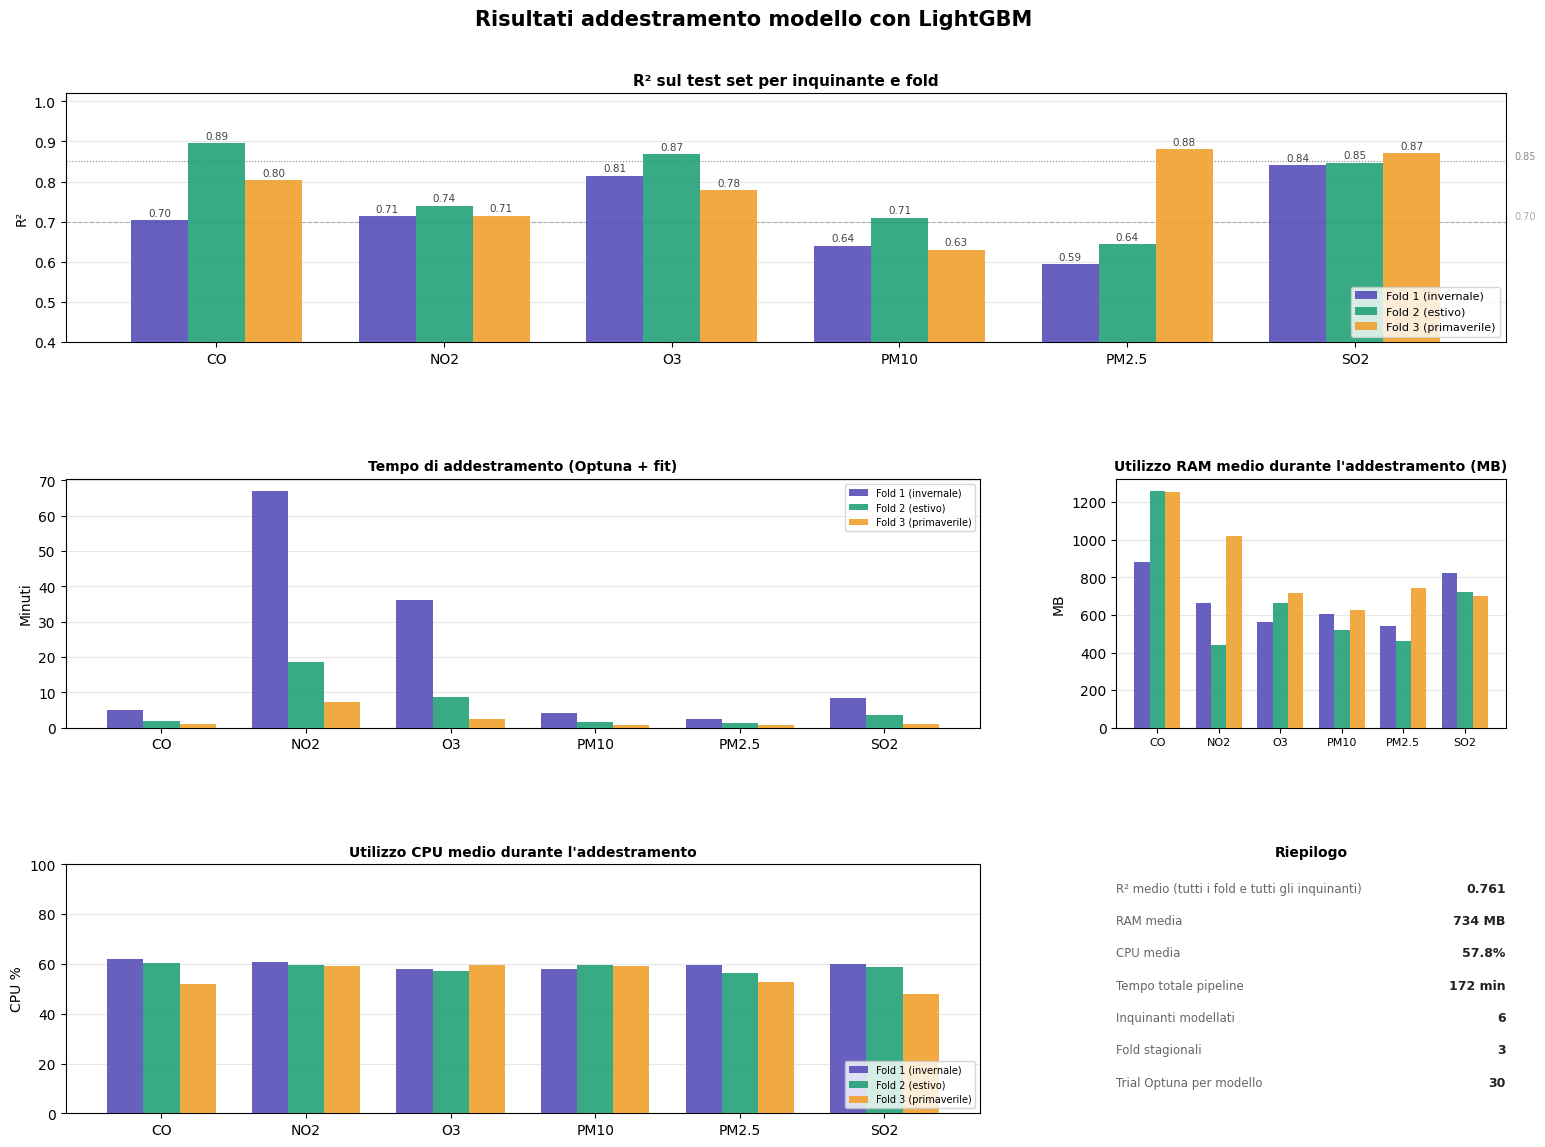

In [4]:
# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("LGBM_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con LightGBM", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0] / 60
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Minuti")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("LGBM_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento SGDRegressor

In [ ]:
FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

N_TRIALS     = 30

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        # ── Clip + trasformazione log ─────────────────────────────
        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            # clip nel dominio log prima di esponenziare:
            # evita overflow numerici su predizioni fuori range
            y_clipped = np.clip(y, -10, 20)
            return np.expm1(y_clipped)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # ── Scaling (fittato solo su train) ──────────────────────
        scaler     = StandardScaler().fit(X_train)
        X_train_sc = scaler.transform(X_train)
        X_val_sc   = scaler.transform(X_val)
        X_test_sc  = scaler.transform(X_test)

        y_train_arr = np.array(y_train)
        y_val_arr   = np.array(y_val)
        y_test_arr  = np.array(y_test)

        # ── Optuna + fit finale con monitoraggio ──────────────────
        # Monitor avviato PRIMA di study.optimize() per includere
        # il tempo di tuning nel tempo totale misurato.
        monitor = ResourceMonitor().start()

        def objective(trial):
            params = {
                "alpha":         trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
                "epsilon":       trial.suggest_float("epsilon", 1e-3, 0.5, log=True),
                "eta0":          trial.suggest_float("eta0", 1e-5, 1e-2, log=True),
                "learning_rate": trial.suggest_categorical(
                                     "learning_rate", ["invscaling", "adaptive"]),
                "power_t":       trial.suggest_float("power_t", 0.1, 0.5),
            }
            m = SGDRegressor(
                loss="epsilon_insensitive",
                penalty="l2",
                max_iter=1000,
                tol=1e-4,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                random_state=42,
                **params,
            )
            m.fit(X_train_sc, y_train_arr)
            return mean_squared_error(y_val_arr, m.predict(X_val_sc)) ** 0.5

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")

        # ── Fit finale ────────────────────────────────────────────
        model = SGDRegressor(
            loss="epsilon_insensitive",
            penalty="l2",
            max_iter=1000,
            tol=1e-4,
            early_stopping=True,
            n_iter_no_change=10,
            validation_fraction=0.1,
            random_state=42,
            alpha=best["alpha"],
            epsilon=best["epsilon"],
            eta0=best["eta0"],
            learning_rate=best["learning_rate"],
            power_t=best["power_t"],
        )
        model.fit(X_train_sc, y_train_arr)

        monitor.stop()
        monitor.report()

        # ── Metriche ─────────────────────────────────────────────
        def metrics(name, X_sc, y_log):
            pred = inverse_y(model.predict(X_sc))
            true = inverse_y(y_log)
            pred = np.clip(pred, 0, None)   # predizioni negative non hanno senso
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_train_sc, y_train_arr)
        pred_v, true_v = metrics("Val",  X_val_sc,  y_val_arr)
        pred_t, true_t = metrics("Test", X_test_sc, y_test_arr)

        # ── Feature importance (|coef| × scale) ──────────────────
        importances = pd.Series(
            np.abs(model.coef_) * scaler.scale_,
            index=FEATURES,
        ).sort_values(ascending=False)
        top3 = ", ".join(importances.head(3).index.tolist())
        print(f"  Top features: {top3}")

        # ── Salvataggio risultati ─────────────────────────────────
        out = pd.DataFrame(X_test_sc, columns=FEATURES).copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":         fold["name"],
            "pollutant":    pollutant,
            "n_train":      len(X_train),
            "n_val":        len(X_val),
            "n_test":       len(X_test),
            "test_mae":     mean_absolute_error(true_t, pred_t),
            "test_rmse":    np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":      r2_score(true_t, pred_t),
            "top3_feat":    top3,
            "train_time_s": round(monitor.elapsed_s, 1),
            "ram_delta_mb": round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":  round(monitor.ram_mean_mb, 1),
            "cpu_pct":      round(monitor.cpu_pct, 1),
            "best_params":  str(best),
        })

# ─────────────────────────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold", "pollutant", "n_train", "n_test",
               "test_mae", "test_rmse", "test_r2",
               "train_time_s", "ram_mean_mb", "cpu_pct"]].to_string(index=False))

summary.to_csv("SGD_SVM_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Migliori iperparametri: {'alpha': 0.0002830887040663654, 'epsilon': 0.16193328925162598, 'eta0': 5.5711412089288836e-05, 'learning_rate': 'invscaling', 'power_t': 0.34885743531614516}
  Tempo di addestramento + fine tuning          : 425.6s
  RAM media utilizzata                          : 913 MB
  CPU utilizzata                                : 12.5%
  Train  → MAE=203444.003  RMSE=9822940.653  R²=-1044287455.7507
  Val    → MAE=69645.979  RMSE=5447949.587  R²=-371251380.5209
  Test   → MAE=1083.077  RMSE=153500.327  R²=-161761.6011
  Top features: lag_1h, lag_2h, roll_mean_6h

  ──────────────────

In [31]:
# # ─────────────────────────────────────────────
# # DATI
# # ─────────────────────────────────────────────
# summary = pd.read_csv("SGD_SVM_summary.csv")

# FOLDS = [
#     "Fold 1 — test invernale (nov–dic)",
#     "Fold 2 — test estivo (giu–lug)",
#     "Fold 3 — test primaverile (apr–mag)",
# ]
# FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
# COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
# POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# # ─────────────────────────────────────────────
# # FIGURA
# # ─────────────────────────────────────────────
# fig = plt.figure(figsize=(16, 12))
# fig.suptitle("Risultati addestramento modello con LightGBM", fontsize=15, fontweight="bold", y=0.98)

# # Layout: 3 metric cards in cima, poi R², tempo, RAM
# gs = fig.add_gridspec(3, 3, hspace=0.65, wspace=0.35,
#                       top=0.91, bottom=0.08, left=0.07, right=0.97)

# ax_r2   = fig.add_subplot(gs[0, :])
# ax_time = fig.add_subplot(gs[1, :2])
# ax_ram  = fig.add_subplot(gs[1, 2])
# ax_cpu  = fig.add_subplot(gs[2, :2])
# ax_meta = fig.add_subplot(gs[2, 2])
# ax_meta.axis("off")

# x      = np.arange(len(POLLS))
# width  = 0.25
# offset = [-width, 0, width]

# # ── R² per fold ──────────────────────────────
# for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
#     r2_vals = [
#         summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
#         if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
#         for p in POLLS
#     ]
#     bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
#     for bar, val in zip(bars, r2_vals):
#         if not np.isnan(val):
#             ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
#                        f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

# ax_r2.set_xticks(x)
# ax_r2.set_xticklabels(POLLS)
# ax_r2.set_ylim(0.4, 1.02)
# ax_r2.set_ylabel("R²")
# ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
# ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
# ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
# ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
# ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
# ax_r2.legend(fontsize=8, loc="lower right")
# ax_r2.grid(axis="y", alpha=0.3, zorder=0)
# ax_r2.set_axisbelow(True)

# # ── Tempo di addestramento ────────────────────
# for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
#     times = [
#         summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0]
#         if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
#         for p in POLLS
#     ]
#     ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

# ax_time.set_xticks(x)
# ax_time.set_xticklabels(POLLS)
# ax_time.set_ylabel("Secondi")
# ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
# ax_time.legend(fontsize=7, loc="upper right")
# ax_time.grid(axis="y", alpha=0.3, zorder=0)
# ax_time.set_axisbelow(True)

# # ── RAM media ─────────────────────────────────
# for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
#     rams = [
#         summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
#         if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
#         for p in POLLS
#     ]
#     ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
# ax_ram.set_xticks(x)
# ax_ram.set_xticklabels(POLLS, fontsize=8)
# ax_ram.set_ylabel("MB")
# ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
# ax_ram.grid(axis="y", alpha=0.3, zorder=0)
# ax_ram.set_axisbelow(True)

# # ── CPU media ─────────────────────────────────
# for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
#     cpus = [
#         summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
#         if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
#         for p in POLLS
#     ]
#     ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

# ax_cpu.set_xticks(x)
# ax_cpu.set_xticklabels(POLLS)
# ax_cpu.set_ylabel("CPU %")
# ax_cpu.set_ylim(0, 100)
# ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
# ax_cpu.legend(fontsize=7, loc="lower right")
# ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
# ax_cpu.set_axisbelow(True)

# # ── Riepilogo testuale ────────────────────────
# r2_mean  = summary["test_r2"].mean()
# ram_mean = summary["ram_mean_mb"].mean()
# cpu_mean = summary["cpu_pct"].mean()
# time_tot = summary["train_time_s"].sum() / 60

# lines = [
#     ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
#     ("RAM media",                   f"{ram_mean:.0f} MB"),
#     ("CPU media",                    f"{cpu_mean:.1f}%"),
#     ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
#     ("Inquinanti modellati",         "6"),
#     ("Fold stagionali",              "3"),
#     ("Trial Optuna per modello",     "30"),
# ]
# ax_meta.set_xlim(0, 1)
# ax_meta.set_ylim(0, 1)
# for j, (lbl, val) in enumerate(lines):
#     y_pos = 0.93 - j * 0.13
#     ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
#     ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
# ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# # plt.savefig("LSVM_dashboard.png", dpi=150, bbox_inches="tight")
# plt.show()

# Addestramento Random Forest

In [6]:
FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

N_TRIALS         = 30
 
all_summary = []
all_results = []
 
for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")
 
    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]
 
    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")
 
        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])
 
        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]
 
        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue
 
        train, val, test = add_lag_features(train, val, test)
 
        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)
 
        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))
 
        def inverse_y(y):
            return np.expm1(y)
 
        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]
 
        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))
 
        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")
 
        # Converti in array numpy una volta sola
        X_tr_np  = X_train.values
        y_tr_np  = y_train.values
        X_val_np = X_val.values
        y_val_np = y_val.values
 
        print(f"  Optuna: {N_TRIALS} trial × {50} alberi su "
              f"TUTTE le {len(X_train):,} righe del train")
 
        # ── Optuna + fit finale con monitoraggio ───────────────────
        # Monitor avviato QUI, prima di study.optimize(), così il tempo
        # misurato include tutta la fase di tuning + fit finale.
        monitor = ResourceMonitor().start()
 
        def objective(trial):
            params = {
                "n_estimators":      40,
                "max_depth":         trial.suggest_int("max_depth", 8, 30),
                "max_features":      trial.suggest_categorical(
                                         "max_features",
                                         ["sqrt", "log2", 0.3, 0.5]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 50),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
                "bootstrap":         trial.suggest_categorical(
                                         "bootstrap", [True, False]),
                "n_jobs":       -1,
                "random_state": 42,
            }
            m = RandomForestRegressor(**params)
            m.fit(X_tr_np, y_tr_np)
            return mean_squared_error(y_val_np, m.predict(X_val_np)) ** 0.5
 
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
 
        best = study.best_params
        best.pop("n_estimators", None)
        best["n_estimators"] = 250
        print(f"  Migliori iperparametri: {best}")
 
        # ── Fit finale sull'intero train set ───────────────────────
        model = RandomForestRegressor(
            **best,
            n_jobs=-1,
            random_state=42,
        )
        model.fit(X_tr_np, y_tr_np)
 
        monitor.stop()
 
        print(f"  Numero alberi effettivi: {model.n_estimators}")
        monitor.report()
 
        # ── Metriche ───────────────────────────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true
 
        metrics("Train", X_tr_np, y_tr_np)
        pred_v, true_v = metrics("Val",   X_val_np, y_val_np)
        pred_t, true_t = metrics("Test",  X_test.values, y_test.values)
 
        fi   = pd.Series(model.feature_importances_,
                         index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")
 
        # ── Salvataggio risultati ───────────────────────────────────
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)
 
        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "n_estimators":  model.n_estimators,
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })
 
# ─────────────────────────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold", "pollutant", "n_train", "n_test",
               "test_mae", "test_rmse", "test_r2",
               "train_time_s", "ram_mean_mb", "cpu_pct"]].to_string(index=False))
 
summary.to_csv("RF_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Optuna: 30 trial × 50 alberi su TUTTE le 429,149 righe del train
  Migliori iperparametri: {'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 11, 'min_samples_split': 9, 'bootstrap': False, 'n_estimators': 250}
  Numero alberi effettivi: 250
  Tempo di addestramento + fine tuning          : 575.0s
  RAM media utilizzata                          : 2005 MB
  CPU utilizzata                                : 89.6%
  Train  → MAE=36.444  RMSE=79.236  R²=0.9321
  Val    → MAE=66.333  RMSE=125.358  R²=0.8034
  Test   → MAE=122.930  RMSE=212.260  R²=0.6907
  Top features: lag_1h, lag_2h, roll_mean_6h

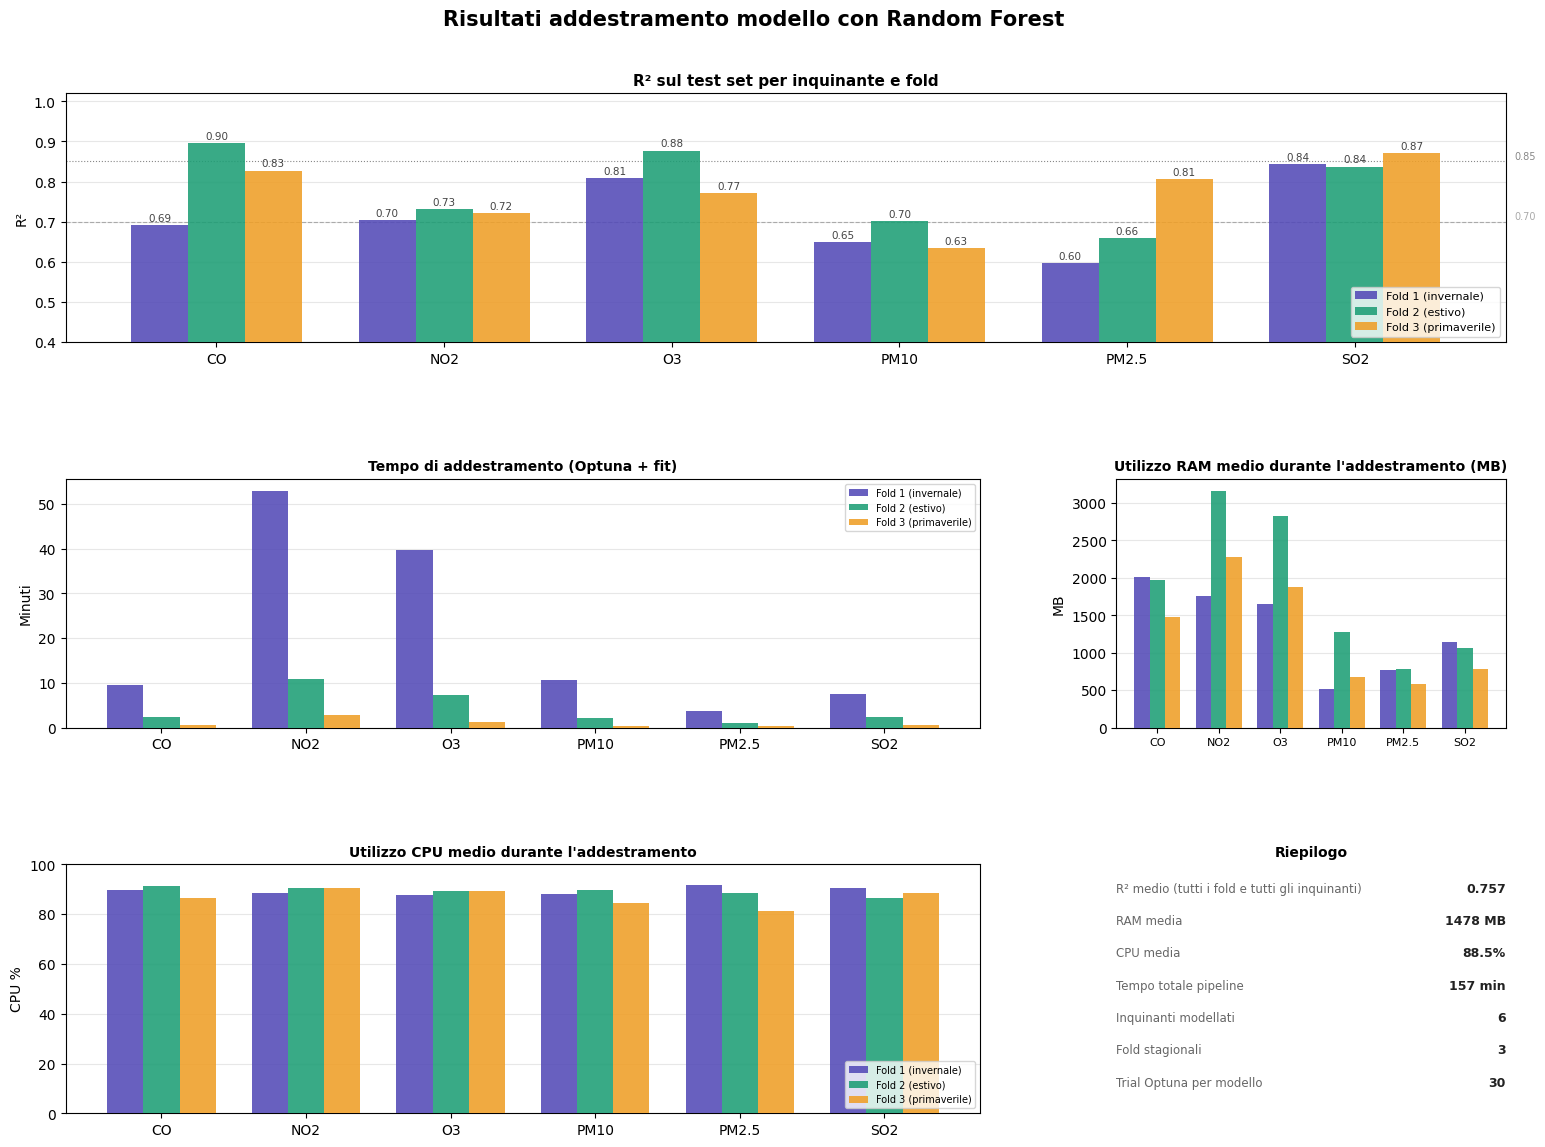

In [5]:
# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("RF_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con Random Forest", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0] / 60
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Minuti")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("RF_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Addestramento Decision Trees

In [8]:
FOLDS = [
    {
        "name":          "Fold 1 — test invernale (nov–dic)",
        "cutoff_train":  pd.Timestamp("2025-09-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-10-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-12-31 23:59:59"),
    },
    {
        "name":          "Fold 2 — test estivo (giu–lug)",
        "cutoff_train":  pd.Timestamp("2025-04-30 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-05-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-07-31 23:59:59"),
    },
    {
        "name":          "Fold 3 — test primaverile (apr–mag)",
        "cutoff_train":  pd.Timestamp("2025-02-28 23:59:59"),
        "cutoff_val":    pd.Timestamp("2025-03-31 23:59:59"),
        "test_end":      pd.Timestamp("2025-05-31 23:59:59"),
    },
]

N_TRIALS     = 30

all_summary = []
all_results = []

for fold in FOLDS:
    print(f"\n{'═'*62}")
    print(f"  {fold['name']}")
    print(f"{'═'*62}")

    ct = fold["cutoff_train"]
    cv = fold["cutoff_val"]
    te = fold["test_end"]

    for pollutant, df_poll in df.groupby("pollutant_notation"):
        label = df_poll["pollutant_label"].iloc[0]
        print(f"\n  {'─'*58}")
        print(f"  {pollutant}  ({label})  — {len(df_poll):,} record")
        print(f"  {'─'*58}")

        df_poll = df_poll[df_poll["data_record_start_time"] <= te].copy()
        df_poll = df_poll.sort_values(["station_id", "data_record_start_time"])

        train = df_poll[df_poll["data_record_start_time"] <= ct]
        val   = df_poll[(df_poll["data_record_start_time"] > ct) &
                        (df_poll["data_record_start_time"] <= cv)]
        test  = df_poll[df_poll["data_record_start_time"] > cv]

        if len(train) < 100 or len(val) < 10 or len(test) < 10:
            print("  ⚠ Dati insufficienti, skip.")
            continue

        train, val, test = add_lag_features(train, val, test)

        lo = max(train["data_record_value"].quantile(0.005), 0.0)
        hi = train["data_record_value"].quantile(0.995)

        def transform_y(y, lo=lo, hi=hi):
            return np.log1p(y.clip(lower=lo, upper=hi))

        def inverse_y(y):
            return np.expm1(y)

        def clean(df_s, y_s):
            mask = df_s[FEATURES].notna().all(axis=1) & y_s.notna()
            return df_s[mask][FEATURES], y_s[mask]

        X_train, y_train = clean(train, transform_y(train["data_record_value"]))
        X_val,   y_val   = clean(val,   transform_y(val["data_record_value"]))
        X_test,  y_test  = clean(test,  transform_y(test["data_record_value"]))

        total = len(df_poll)
        print(f"  Train={len(X_train):,} ({100*len(X_train)/total:.0f}%)  "
              f"Val={len(X_val):,} ({100*len(X_val)/total:.0f}%)  "
              f"Test={len(X_test):,} ({100*len(X_test)/total:.0f}%)")

        # Converti in array numpy una volta sola
        X_tr_np  = X_train.values
        y_tr_np  = y_train.values
        X_val_np = X_val.values
        y_val_np = y_val.values

        print(f"  Optuna: {N_TRIALS} trial su TUTTE le {len(X_train):,} righe del train")

        # ── Optuna ─────────────────────────────────────────────────
        # DT è veloce anche su 5M righe → nessun sottoinsieme necessario.
        # Lo spazio degli iperparametri è lo stesso di RF (meno bootstrap/
        # max_features che qui hanno ruolo diverso) più criterion e splitter.
        
        monitor = ResourceMonitor().start()
        
        def objective(trial):
            params = {
                "max_depth":         trial.suggest_int("max_depth", 3, 30),
                "max_features":      trial.suggest_categorical(
                                         "max_features",
                                         ["sqrt", "log2", None, 0.3, 0.5]),
                "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 100),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
                "criterion":         trial.suggest_categorical(
                                         "criterion",
                                         ["squared_error", "friedman_mse"]),
                "splitter":          trial.suggest_categorical(
                                         "splitter", ["best", "random"]),
                "random_state": 42,
            }
            m = DecisionTreeRegressor(**params)
            m.fit(X_tr_np, y_tr_np)
            return mean_squared_error(y_val_np, m.predict(X_val_np)) ** 0.5

        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
        best = study.best_params
        print(f"  Migliori iperparametri: {best}")


        model = DecisionTreeRegressor(
            **best,
            random_state=42,
        )
        model.fit(X_tr_np, y_tr_np)

        monitor.stop()

        print(f"  Profondità effettiva: {model.get_depth()}  "
              f"  N° foglie: {model.get_n_leaves():,}")
        monitor.report()

        # ── Metriche ───────────────────────────────────────────────
        def metrics(name, X, y_log):
            pred = inverse_y(model.predict(X))
            true = inverse_y(y_log)
            mae  = mean_absolute_error(true, pred)
            rmse = np.sqrt(mean_squared_error(true, pred))
            r2   = r2_score(true, pred)
            print(f"  {name:6s} → MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
            return pred, true

        metrics("Train", X_tr_np, y_tr_np)
        pred_v, true_v = metrics("Val",   X_val_np, y_val_np)
        pred_t, true_t = metrics("Test",  X_test.values, y_test.values)

        # Feature importance (impurity-based)
        fi   = pd.Series(model.feature_importances_,
                         index=FEATURES).sort_values(ascending=False)
        top3 = ", ".join(fi.head(3).index.tolist())
        print(f"  Top features: {top3}")

        # ── Salvataggio risultati ───────────────────────────────────
        out = X_test.copy()
        out["fold"]      = fold["name"]
        out["pollutant"] = pollutant
        out["y_true"]    = true_t
        out["y_pred"]    = pred_t
        all_results.append(out)

        all_summary.append({
            "fold":          fold["name"],
            "pollutant":     pollutant,
            "n_train":       len(X_train),
            "n_val":         len(X_val),
            "n_test":        len(X_test),
            "tree_depth":    model.get_depth(),
            "n_leaves":      model.get_n_leaves(),
            "test_mae":      mean_absolute_error(true_t, pred_t),
            "test_rmse":     np.sqrt(mean_squared_error(true_t, pred_t)),
            "test_r2":       r2_score(true_t, pred_t),
            "top3_feat":     top3,
            "train_time_s":  round(monitor.elapsed_s, 1),
            "ram_delta_mb":  round(monitor.ram_delta_mb, 1),
            "ram_mean_mb":   round(monitor.ram_mean_mb, 1),
            "cpu_pct":       round(monitor.cpu_pct, 1),
            "best_params":   str(best),
        })

# ─────────────────────────────────────────────────────────────────
# RIEPILOGO
# ─────────────────────────────────────────────────────────────────
print(f"\n{'═'*62}")
print("  RIEPILOGO TEST SET — tutti i fold")
print(f"{'═'*62}")
summary = pd.DataFrame(all_summary)
print(summary[["fold", "pollutant", "n_train", "n_test",
               "test_mae", "test_rmse", "test_r2",
               "tree_depth", "n_leaves",
               "train_time_s", "ram_mean_mb", "cpu_pct"]].to_string(index=False))

summary.to_csv("DT_summary.csv", index=False)


══════════════════════════════════════════════════════════════
  Fold 1 — test invernale (nov–dic)
══════════════════════════════════════════════════════════════

  ──────────────────────────────────────────────────────────
  CO  (Carbon monoxide (air))  — 523,173 record
  ──────────────────────────────────────────────────────────
  Train=429,149 (82%)  Val=39,343 (8%)  Test=51,015 (10%)
  Optuna: 30 trial su TUTTE le 429,149 righe del train
  Migliori iperparametri: {'max_depth': 14, 'max_features': None, 'min_samples_leaf': 82, 'min_samples_split': 16, 'criterion': 'friedman_mse', 'splitter': 'best'}
  Profondità effettiva: 14    N° foglie: 1,900
  Tempo di addestramento + fine tuning          : 87.6s
  RAM media utilizzata                          : 1231 MB
  CPU utilizzata                                : 12.4%
  Train  → MAE=52.168  RMSE=103.206  R²=0.8847
  Val    → MAE=70.469  RMSE=129.963  R²=0.7887
  Test   → MAE=129.953  RMSE=220.975  R²=0.6648
  Top features: lag_1h, roll_m

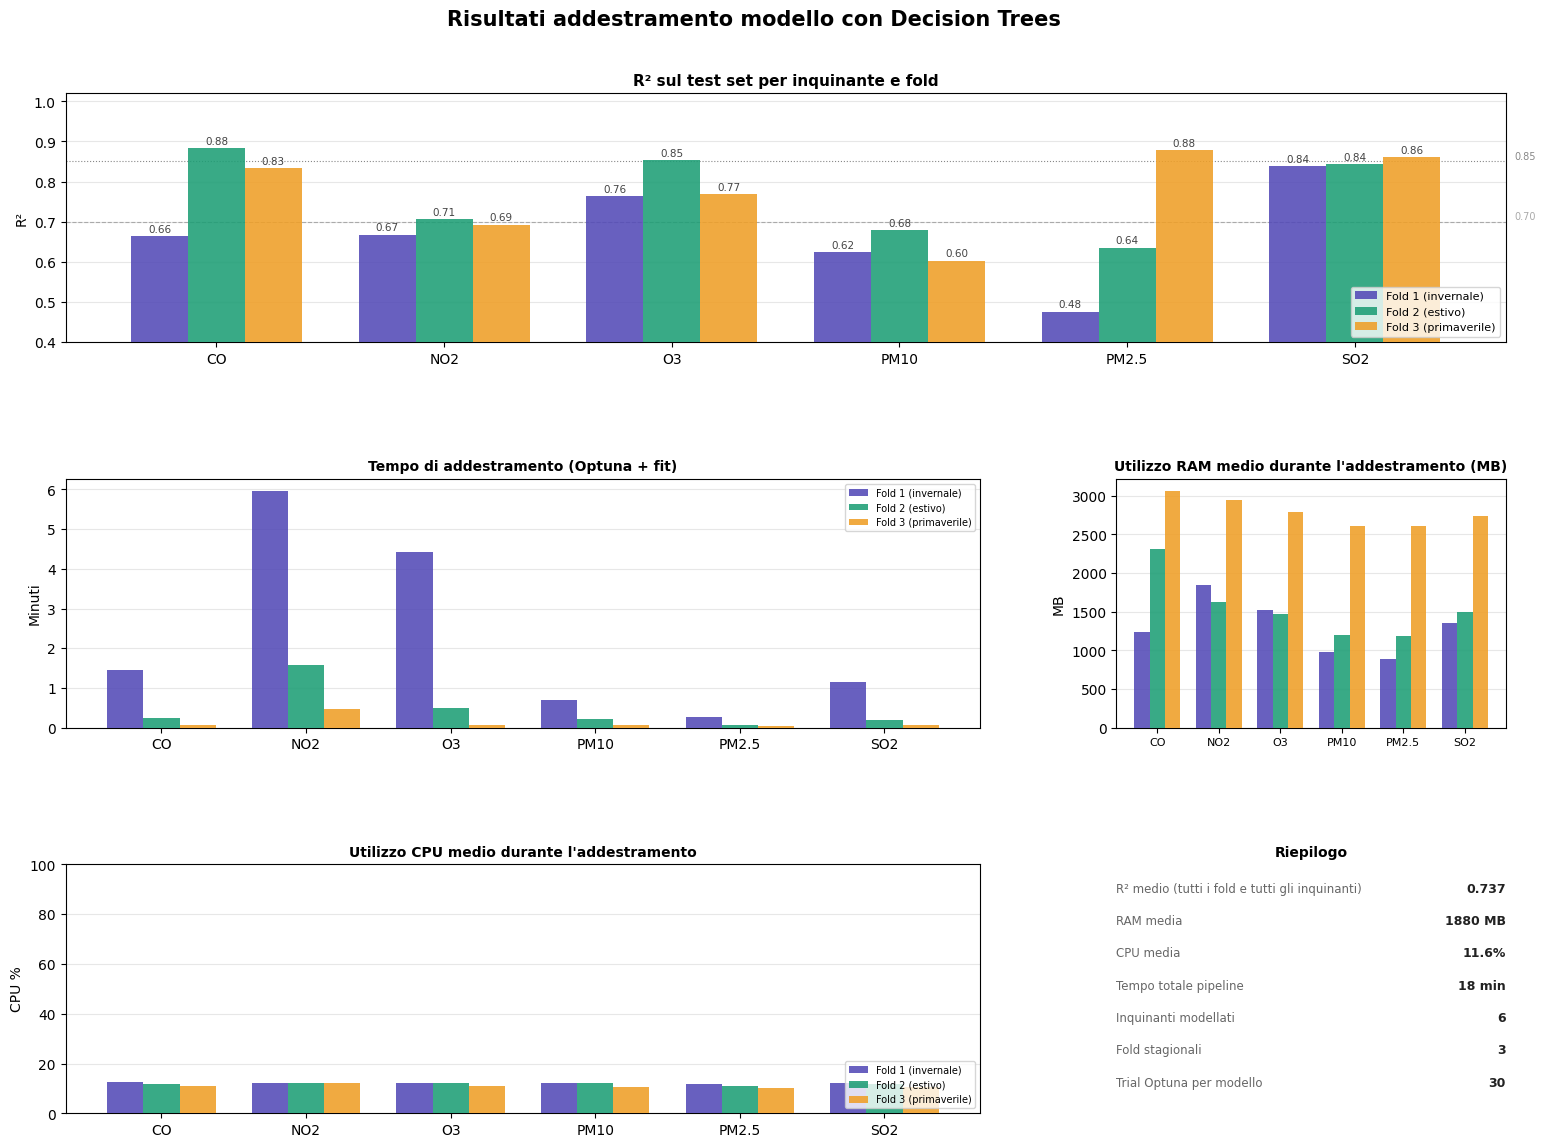

In [6]:
# ─────────────────────────────────────────────
# DATI
# ─────────────────────────────────────────────
summary = pd.read_csv("DT_summary.csv")

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 (invernale)", "Fold 2 (estivo)", "Fold 3 (primaverile)"]
COLORS      = ["#534AB7", "#1D9E75", "#EF9F27"]
POLLS       = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Risultati addestramento modello con Decision Trees", fontsize=15, fontweight="bold", y=0.98)

# Layout: 3 metric cards in cima, poi R², tempo, RAM
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35,
                      top=0.91, bottom=0.06, left=0.07, right=0.97)

ax_r2   = fig.add_subplot(gs[0, :])
ax_time = fig.add_subplot(gs[1, :2])
ax_ram  = fig.add_subplot(gs[1, 2])
ax_cpu  = fig.add_subplot(gs[2, :2])
ax_meta = fig.add_subplot(gs[2, 2])
ax_meta.axis("off")

x      = np.arange(len(POLLS))
width  = 0.25
offset = [-width, 0, width]

# ── R² per fold ──────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    r2_vals = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["test_r2"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    bars = ax_r2.bar(x + off, r2_vals, width, label=label, color=color, alpha=0.88, zorder=3)
    for bar, val in zip(bars, r2_vals):
        if not np.isnan(val):
            ax_r2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                       f"{val:.2f}", ha="center", va="bottom", fontsize=7.5, color="#444")

ax_r2.set_xticks(x)
ax_r2.set_xticklabels(POLLS)
ax_r2.set_ylim(0.4, 1.02)
ax_r2.set_ylabel("R²")
ax_r2.set_title("R² sul test set per inquinante e fold", fontweight='bold', fontsize=11)
ax_r2.axhline(0.7, color="#aaa", linewidth=0.8, linestyle="--", zorder=2)
ax_r2.axhline(0.85, color="#888", linewidth=0.8, linestyle=":", zorder=2)
ax_r2.text(5.7, 0.705, "0.70", fontsize=7, color="#aaa")
ax_r2.text(5.7, 0.855, "0.85", fontsize=7, color="#888")
ax_r2.legend(fontsize=8, loc="lower right")
ax_r2.grid(axis="y", alpha=0.3, zorder=0)
ax_r2.set_axisbelow(True)

# ── Tempo di addestramento ────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    times = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["train_time_s"].values[0] / 60
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_time.bar(x + off, times, width, label=label, color=color, alpha=0.88, zorder=3)

ax_time.set_xticks(x)
ax_time.set_xticklabels(POLLS)
ax_time.set_ylabel("Minuti")
ax_time.set_title("Tempo di addestramento (Optuna + fit)", fontweight='bold', fontsize=10)
ax_time.legend(fontsize=7, loc="upper right")
ax_time.grid(axis="y", alpha=0.3, zorder=0)
ax_time.set_axisbelow(True)

# ── RAM media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    rams = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["ram_mean_mb"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_ram.bar(x + off, rams, width, label=label, color=color, alpha=0.88, zorder=3)
 
ax_ram.set_xticks(x)
ax_ram.set_xticklabels(POLLS, fontsize=8)
ax_ram.set_ylabel("MB")
ax_ram.set_title("Utilizzo RAM medio durante l'addestramento (MB)",fontweight='bold', fontsize=10)
ax_ram.grid(axis="y", alpha=0.3, zorder=0)
ax_ram.set_axisbelow(True)

# ── CPU media ─────────────────────────────────
for i, (fold, label, color, off) in enumerate(zip(FOLDS, FOLD_LABELS, COLORS, offset)):
    cpus = [
        summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]["cpu_pct"].values[0]
        if len(summary[(summary["fold"] == fold) & (summary["pollutant"] == p)]) > 0 else np.nan
        for p in POLLS
    ]
    ax_cpu.bar(x + off, cpus, width, label=label, color=color, alpha=0.88, zorder=3)

ax_cpu.set_xticks(x)
ax_cpu.set_xticklabels(POLLS)
ax_cpu.set_ylabel("CPU %")
ax_cpu.set_ylim(0, 100)
ax_cpu.set_title("Utilizzo CPU medio durante l'addestramento",fontweight='bold', fontsize=10)
ax_cpu.legend(fontsize=7, loc="lower right")
ax_cpu.grid(axis="y", alpha=0.3, zorder=0)
ax_cpu.set_axisbelow(True)

# ── Riepilogo testuale ────────────────────────
r2_mean  = summary["test_r2"].mean()
ram_mean = summary["ram_mean_mb"].mean()
cpu_mean = summary["cpu_pct"].mean()
time_tot = summary["train_time_s"].sum() / 60

lines = [
    ("R² medio (tutti i fold e tutti gli inquinanti)",     f"{r2_mean:.3f}"),
    ("RAM media",                   f"{ram_mean:.0f} MB"),
    ("CPU media",                    f"{cpu_mean:.1f}%"),
    ("Tempo totale pipeline",        f"{time_tot:.0f} min"),
    ("Inquinanti modellati",         "6"),
    ("Fold stagionali",              "3"),
    ("Trial Optuna per modello",     "30"),
]
ax_meta.set_xlim(0, 1)
ax_meta.set_ylim(0, 1)
for j, (lbl, val) in enumerate(lines):
    y_pos = 0.93 - j * 0.13
    ax_meta.text(0.0, y_pos, lbl, fontsize=8.5, color="#666", va="top")
    ax_meta.text(1.0, y_pos, val, fontsize=9, fontweight="bold", color="#222", va="top", ha="right")
ax_meta.set_title("Riepilogo", fontweight='bold', fontsize=10)

# plt.savefig("DT_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# Riassunto risultati

- Analisi R2 per ogni agente inquinante e per ogni fold 

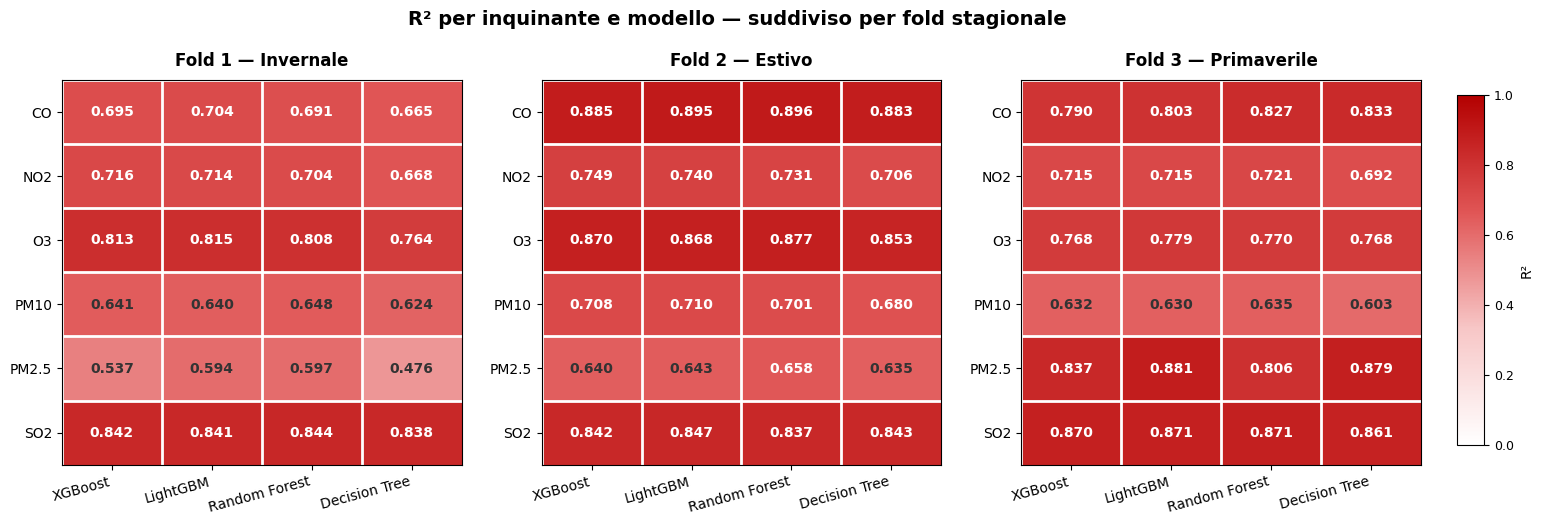

In [3]:
summaries = {
    "XGBoost":       pd.read_csv("XGBoost_summary.csv"),
    "LightGBM":      pd.read_csv("LGBM_summary.csv"),
    "Random Forest": pd.read_csv("RF_summary.csv"),
    "Decision Tree": pd.read_csv("DT_summary.csv"),
}

models     = list(summaries.keys())
pollutants = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 — Invernale", "Fold 2 — Estivo", "Fold 3 — Primaverile"]

# Colormap bianco → rosso
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_red", ["#ffffff", "#f7c6c6", "#e05555", "#b30000"]
)

# ─────────────────────────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(right=0.88)
fig.patch.set_facecolor("white")
fig.suptitle(
    "R² per inquinante e modello — suddiviso per fold stagionale",
    fontsize=14, fontweight="bold", y=1.02,
)

for ax, fold, fold_label in zip(axes, FOLDS, FOLD_LABELS):

    # ── Costruzione matrice per questo fold ───────────────────────
    matrix = np.full((len(pollutants), len(models)), np.nan)
    for j, model in enumerate(models):
        df = summaries[model]
        df_fold = df[df["fold"] == fold]
        for i, poll in enumerate(pollutants):
            vals = df_fold[df_fold["pollutant"] == poll]["test_r2"]
            if len(vals) > 0:
                matrix[i, j] = vals.values[0]

    # ── Heatmap ───────────────────────────────────────────────────
    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    # Etichette assi
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, fontsize=10, rotation=15, ha="right")
    ax.set_yticks(np.arange(len(pollutants)))
    ax.set_yticklabels(pollutants, fontsize=10)
    ax.xaxis.set_ticks_position("bottom")

    # Valori nelle celle
    for i in range(len(pollutants)):
        for j in range(len(models)):
            val = matrix[i, j]
            if not np.isnan(val):
                text_color = "white" if val > 0.65 else "#333333"
                ax.text(j, i, f"{val:.3f}",
                        ha="center", va="center",
                        fontsize=10, fontweight="bold", color=text_color)

    # Griglia bianca tra celle
    ax.set_xticks(np.arange(len(models)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(pollutants)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)

    ax.set_title(fold_label, fontsize=12, fontweight="bold", pad=10)

# ── Colorbar condivisa ────────────────────────────────────────────
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("R²", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# plt.savefig("r2_heatmap_by_fold.png", dpi=150, bbox_inches="tight")
plt.show()

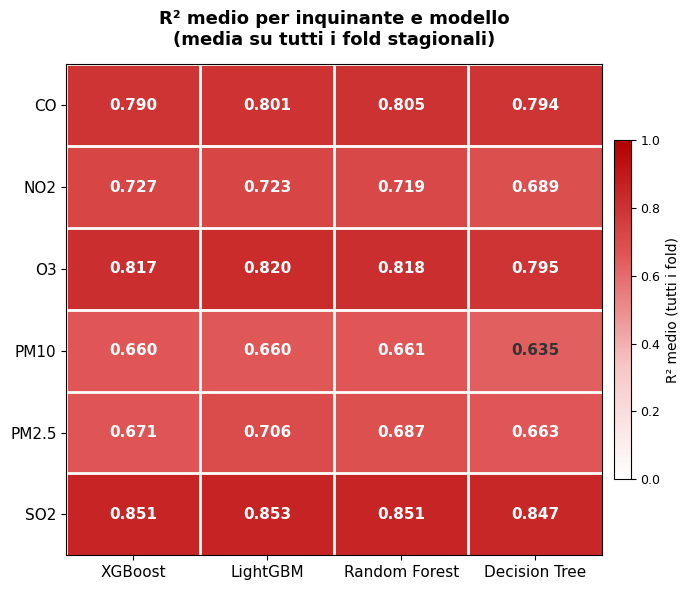

In [4]:
models     = list(summaries.keys())
pollutants = ["CO", "NO2", "O3", "PM10", "PM2.5", "SO2"]

# ─────────────────────────────────────────────────────────────────
# COSTRUZIONE MATRICE R² (media su tutti i fold)
# ─────────────────────────────────────────────────────────────────

matrix = np.full((len(pollutants), len(models)), np.nan)

for j, model in enumerate(models):
    df = summaries[model]
    for i, poll in enumerate(pollutants):
        vals = df[df["pollutant"] == poll]["test_r2"]
        if len(vals) > 0:
            matrix[i, j] = vals.mean()

# ─────────────────────────────────────────────────────────────────
# FIGURA
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Colormap bianco → rosso, clamp tra 0 e 1
cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_red", ["#ffffff", "#f7c6c6", "#e05555", "#b30000"]
)
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, aspect="auto")

# ── Etichette assi ────────────────────────────────────────────────
ax.set_xticks(np.arange(len(models)))
ax.set_xticklabels(models, fontsize=11)
ax.set_yticks(np.arange(len(pollutants)))
ax.set_yticklabels(pollutants, fontsize=11)
ax.xaxis.set_ticks_position("bottom")

# ── Valori nelle celle ────────────────────────────────────────────
for i in range(len(pollutants)):
    for j in range(len(models)):
        val = matrix[i, j]
        if not np.isnan(val):
            # testo scuro su celle chiare, bianco su celle scure
            text_color = "white" if val > 0.65 else "#333333"
            ax.text(j, i, f"{val:.3f}",
                    ha="center", va="center",
                    fontsize=11, fontweight="bold", color=text_color)

# ── Colorbar ──────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("R² medio (tutti i fold)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# ── Griglia leggera tra le celle ─────────────────────────────────
ax.set_xticks(np.arange(len(models)) - 0.5, minor=True)
ax.set_yticks(np.arange(len(pollutants)) - 0.5, minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="minor", length=0)

ax.set_title(
    "R² medio per inquinante e modello\n(media su tutti i fold stagionali)",
    fontsize=13, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.show()
# plt.savefig("r2_heatmap.png", dpi=150, bbox_inches="tight")

- Analisi di R2, tempo di training + fine-tuning, percentuale media di CPU e RAM media per fold

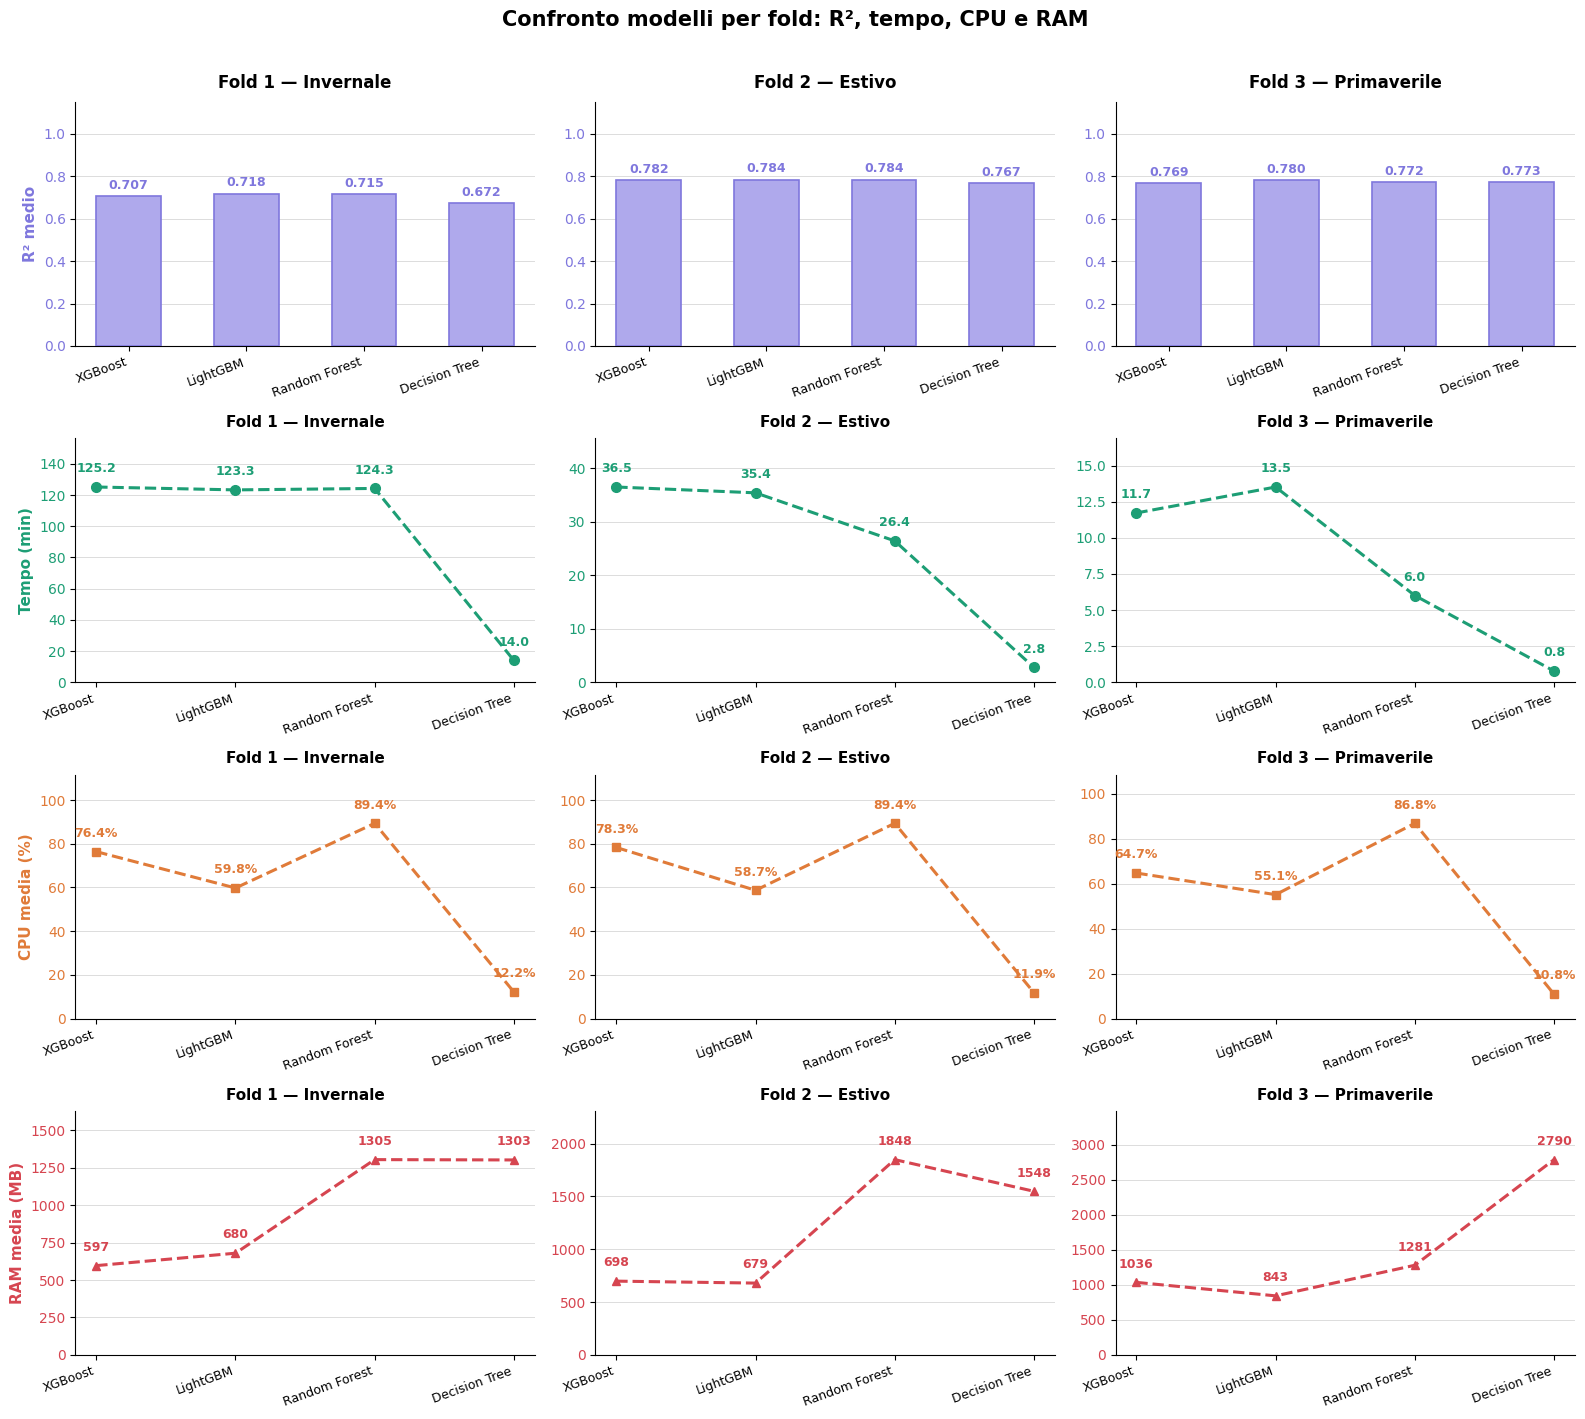

In [14]:
# ─────────────────────────────────────────────────────────────────
# CARICAMENTO DATI
# ─────────────────────────────────────────────────────────────────

summaries = {
    "XGBoost":       pd.read_csv("XGBoost_summary.csv"),
    "LightGBM":      pd.read_csv("LGBM_summary.csv"),
    "Random Forest": pd.read_csv("RF_summary.csv"),
    "Decision Tree": pd.read_csv("DT_summary.csv"),
}

models = list(summaries.keys())

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS = ["Fold 1 — Invernale", "Fold 2 — Estivo", "Fold 3 — Primaverile"]

# ─────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────

BAR_COLOR  = "#AFA9EC"
BAR_EDGE   = "#7F77DD"
COLOR_TIME = "#1D9E75"
COLOR_CPU  = "#E07B39"
COLOR_RAM  = "#D64550"

# ─────────────────────────────────────────────────────────────────
# FIGURA: 4 righe (R², Tempo, CPU, RAM) × 3 colonne (fold)
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=False)
fig.patch.set_facecolor("white")

fig.suptitle(
    "Confronto modelli per fold: R², tempo, CPU e RAM",
    fontsize=15, fontweight="bold", y=1.01,
)

x         = np.arange(len(models))
bar_width = 0.55

for col, (fold, fold_label) in enumerate(zip(FOLDS, FOLD_LABELS)):

    # ── Dati per questo fold ──────────────────────────────────────
    r2_means = [
        summaries[m][summaries[m]["fold"] == fold]["test_r2"].mean()
        for m in models
    ]
    time_totals = [
        summaries[m][summaries[m]["fold"] == fold]["train_time_s"].sum() / 60
        for m in models
    ]
    cpu_means = [
        summaries[m][summaries[m]["fold"] == fold]["cpu_pct"].mean()
        for m in models
    ]
    ram_means = [
        summaries[m][summaries[m]["fold"] == fold]["ram_mean_mb"].mean()
        for m in models
    ]

    # ── Riga 0: R² (barre) ──────────────────────────────────────────
    ax = axes[0, col]
    bars = ax.bar(x, r2_means, width=bar_width, color=BAR_COLOR,
                   edgecolor=BAR_EDGE, linewidth=1.2, zorder=3)
    for bar, val in zip(bars, r2_means):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{val:.3f}", ha="center", va="bottom",
                     fontsize=9, color=BAR_EDGE, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_title(fold_label, fontsize=12, fontweight="bold", pad=10)
    if col == 0:
        ax.set_ylabel("R² medio", color=BAR_EDGE, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelcolor=BAR_EDGE)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9, rotation=20, ha="right")

    # ── Riga 1: Tempo (linea) ───────────────────────────────────────
    ax = axes[1, col]
    ax.plot(x, time_totals, color=COLOR_TIME, linewidth=2.2, linestyle="--",
            marker="o", markersize=7, zorder=3)
    for xi, val in zip(x, time_totals):
        if not np.isnan(val):
            ax.text(xi, val + (max(time_totals) * 0.06), f"{val:.1f}",
                     ha="center", va="bottom", fontsize=9,
                     color=COLOR_TIME, fontweight="bold")
    ax.set_ylim(bottom=0, top=max(time_totals) * 1.25)
    ax.set_title(fold_label, fontsize=11, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("Tempo (min)", color=COLOR_TIME, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelcolor=COLOR_TIME)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9, rotation=20, ha="right")

    # ── Riga 2: CPU (linea) ──────────────────────────────────────────
    ax = axes[2, col]
    ax.plot(x, cpu_means, color=COLOR_CPU, linewidth=2.2, linestyle="--",
            marker="s", markersize=6, zorder=3)
    for xi, val in zip(x, cpu_means):
        if not np.isnan(val):
            ax.text(xi, val + (max(cpu_means) * 0.06), f"{val:.1f}%",
                     ha="center", va="bottom", fontsize=9,
                     color=COLOR_CPU, fontweight="bold")
    ax.set_ylim(bottom=0, top=max(cpu_means) * 1.25)
    ax.set_title(fold_label, fontsize=11, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("CPU media (%)", color=COLOR_CPU, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelcolor=COLOR_CPU)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9, rotation=20, ha="right")

    # ── Riga 3: RAM (linea) ──────────────────────────────────────────
    ax = axes[3, col]
    ax.plot(x, ram_means, color=COLOR_RAM, linewidth=2.2, linestyle="--",
            marker="^", markersize=6, zorder=3)
    for xi, val in zip(x, ram_means):
        if not np.isnan(val):
            ax.text(xi, val + (max(ram_means) * 0.06), f"{val:.0f}",
                     ha="center", va="bottom", fontsize=9,
                     color=COLOR_RAM, fontweight="bold")
    ax.set_ylim(bottom=0, top=max(ram_means) * 1.25)
    ax.set_title(fold_label, fontsize=11, fontweight="bold", pad=8)
    if col == 0:
        ax.set_ylabel("RAM media (MB)", color=COLOR_RAM, fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelcolor=COLOR_RAM)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9, rotation=20, ha="right")

plt.tight_layout()
plt.show()

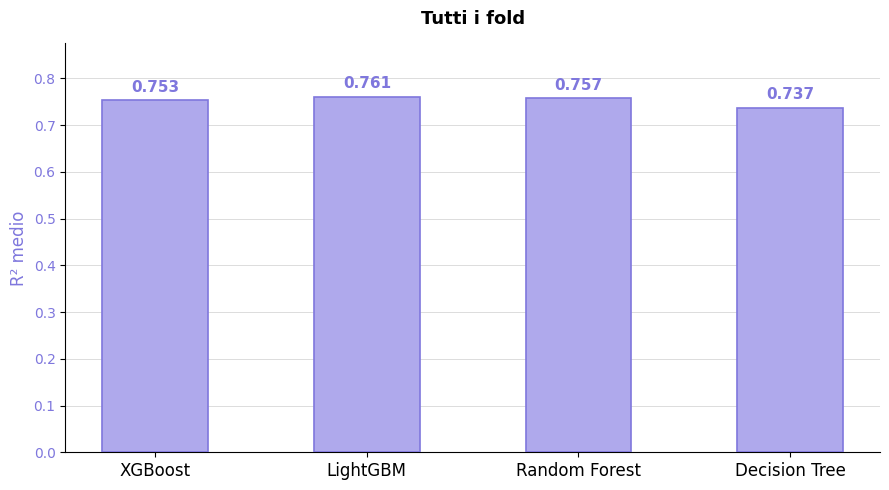

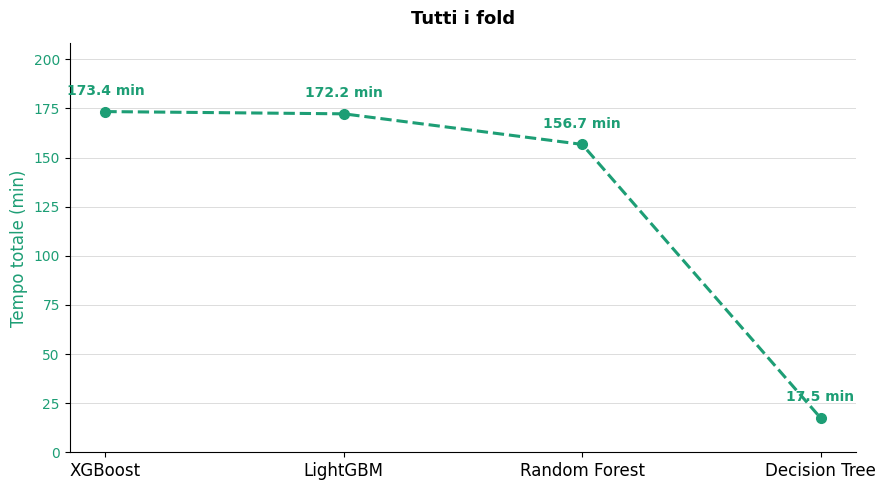

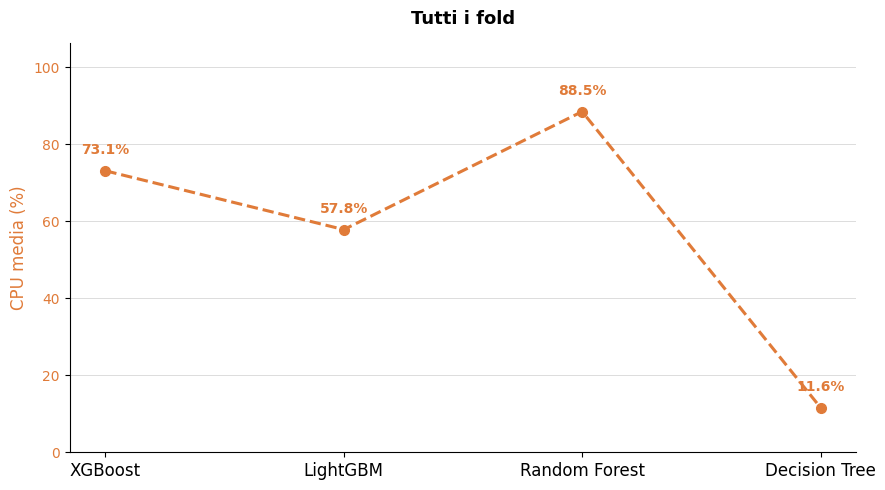

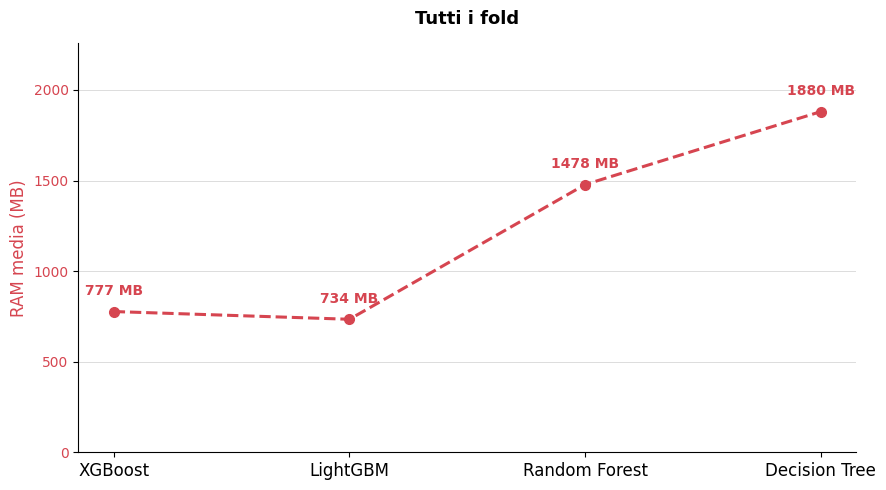

In [12]:
# ─────────────────────────────────────────────────────────────────
# DATI AGGREGATI (tutti i fold x tutti gli inquinanti)
# ─────────────────────────────────────────────────────────────────

models      = list(summaries.keys())
r2_means    = [summaries[m]["test_r2"].mean()        for m in models]
time_totals = [summaries[m]["train_time_s"].sum() / 60 for m in models]
cpu_means   = [summaries[m]["cpu_pct"].mean()          for m in models]
ram_means   = [summaries[m]["ram_mean_mb"].mean()      for m in models]

# ─────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────

BAR_COLOR  = "#AFA9EC" 
BAR_EDGE   = "#7F77DD" 
COLOR_TIME = "#1D9E75" 
COLOR_CPU  = "#E07B39" 
COLOR_RAM  = "#D64550" 

x         = np.arange(len(models))
bar_width = 0.5


def plot_bar_metric(values, ylabel, color, edge_color, value_fmt, title):

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    bars = ax.bar(
        x, values,
        width=bar_width,
        color=color,
        edgecolor=edge_color,
        linewidth=1.2,
        zorder=3,
    )

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (max(values) * 0.015),
            value_fmt(val),
            ha="center", va="bottom",
            fontsize=11, color=edge_color, fontweight="bold",
        )

    ax.set_ylim(0, max(values) * 1.15)
    ax.set_ylabel(ylabel, color=edge_color, fontsize=12)
    ax.tick_params(axis="y", labelcolor=edge_color)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=12)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    plt.title(
        "Tutti i fold",
        fontsize=13,
        pad=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


def plot_line_metric(values, ylabel, color, value_fmt, title):

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.plot(
        x, values,
        color=color,
        linewidth=2.2,
        linestyle="--",
        marker="o",
        markersize=7,
        zorder=4,
    )

    for xi, val in zip(x, values):
        ax.text(
            xi, val + (max(values) * 0.04),
            value_fmt(val),
            ha="center", va="bottom",
            fontsize=10, color=color, fontweight="bold",
        )

    ax.set_ylim(0, max(values) * 1.2)
    ax.set_ylabel(ylabel, color=color, fontsize=12)
    ax.tick_params(axis="y", labelcolor=color)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=12)
    ax.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    plt.title(
        "Tutti i fold",
        fontsize=13,
        pad=14,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


# ─────────────────────────────────────────────────────────────────
# GRAFICO 1: R² medio (barre)
# ─────────────────────────────────────────────────────────────────

plot_bar_metric(
    values=r2_means,
    ylabel="R² medio",
    color=BAR_COLOR,
    edge_color=BAR_EDGE,
    value_fmt=lambda v: f"{v:.3f}",
    title="R² medio",
)

# ─────────────────────────────────────────────────────────────────
# GRAFICO 2: Tempo totale (linea)
# ─────────────────────────────────────────────────────────────────

plot_line_metric(
    values=time_totals,
    ylabel="Tempo totale (min)",
    color=COLOR_TIME,
    value_fmt=lambda v: f"{v:.1f} min",
    title="Tempo totale di addestramento",
)

# ─────────────────────────────────────────────────────────────────
# GRAFICO 3: CPU media (linea)
# ─────────────────────────────────────────────────────────────────

plot_line_metric(
    values=cpu_means,
    ylabel="CPU media (%)",
    color=COLOR_CPU,
    value_fmt=lambda v: f"{v:.1f}%",
    title="CPU media",
)

# ─────────────────────────────────────────────────────────────────
# GRAFICO 4: RAM media (linea)
# ─────────────────────────────────────────────────────────────────

plot_line_metric(
    values=ram_means,
    ylabel="RAM media (MB)",
    color=COLOR_RAM,
    value_fmt=lambda v: f"{v:.0f} MB",
    title="RAM media",
)

# Comparazione R2 ed emissioni

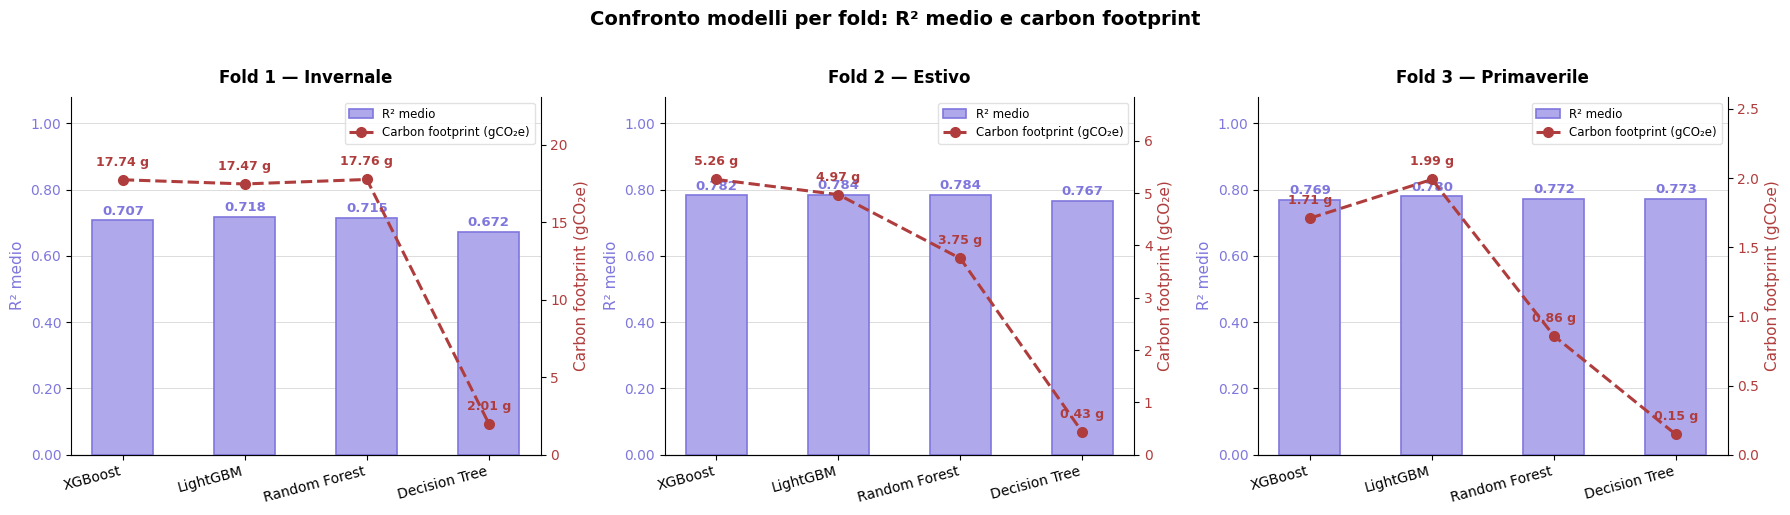

In [7]:
# ─────────────────────────────────────────────────────────────────
# CARICAMENTO DATI
# ─────────────────────────────────────────────────────────────────

summaries = {
    "XGBoost":       pd.read_csv("XGBoost_summary.csv"),
    "LightGBM":      pd.read_csv("LGBM_summary.csv"),
    "Random Forest": pd.read_csv("RF_summary.csv"),
    "Decision Tree": pd.read_csv("DT_summary.csv"),
}

emissions = pd.read_csv("emissioni_modelli.csv")
emissions.columns = emissions.columns.str.strip()          # rimuove eventuali spazi nei nomi colonna
emissions["modello"] = emissions["modello"].str.strip()
emissions["fold"] = emissions["fold"].astype(str).str.strip()

models = list(summaries.keys())

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]
FOLD_LABELS   = ["Fold 1 — Invernale", "Fold 2 — Estivo", "Fold 3 — Primaverile"]
FOLD_CSV_KEYS = ["1", "2", "3"]     # valori corrispondenti nella colonna "fold" del csv emissioni

# ─────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────

BAR_COLOR  = "#AFA9EC"
BAR_EDGE   = "#7F77DD"
CO2_COLOR  = "#B03D3D"

# ─────────────────────────────────────────────────────────────────
# FIGURA: 1 riga, 1 subplot per fold
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
fig.patch.set_facecolor("white")

fig.suptitle(
    "Confronto modelli per fold: R² medio e carbon footprint",
    fontsize=14, fontweight="bold", y=1.02,
)

x         = np.arange(len(models))
bar_width = 0.5

for ax1, fold, fold_label, fold_key in zip(axes, FOLDS, FOLD_LABELS, FOLD_CSV_KEYS):

    # ── Dati R² per questo fold ──────────────────────────────────
    r2_means = [
        summaries[m][summaries[m]["fold"] == fold]["test_r2"].mean()
        for m in models
    ]

    # ── Dati carbon footprint per questo fold ────────────────────
    co2_values = [
        emissions[(emissions["modello"] == m) & (emissions["fold"] == fold_key)]["carbon_footprint (gCO2e)"].values[0]
        if len(emissions[(emissions["modello"] == m) & (emissions["fold"] == fold_key)]) > 0 else np.nan
        for m in models
    ]

    ax1.set_facecolor("white")

    # ── Barre R² (asse sinistro) ──────────────────────────────────
    bars = ax1.bar(
        x, r2_means,
        width=bar_width,
        color=BAR_COLOR,
        edgecolor=BAR_EDGE,
        linewidth=1.2,
        zorder=3,
        label="R² medio",
    )

    for bar, val in zip(bars, r2_means):
        if not np.isnan(val):
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{val:.3f}",
                ha="center", va="bottom",
                fontsize=9.5, color=BAR_EDGE, fontweight="bold",
            )

    ax1.set_ylim(0, 1.08)
    ax1.set_ylabel("R² medio", color=BAR_EDGE, fontsize=11)
    ax1.tick_params(axis="y", labelcolor=BAR_EDGE)
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, fontsize=10, rotation=15, ha="right")
    ax1.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
    ax1.set_axisbelow(True)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.set_title(fold_label, fontsize=12, fontweight="bold", pad=10)

    # ── Linea carbon footprint (asse destro) ─────────────────────
    ax2 = ax1.twinx()
    ax2.plot(
        x, co2_values,
        color=CO2_COLOR,
        linewidth=2.2,
        linestyle="--",
        marker="o",
        markersize=7,
        zorder=4,
        label="Carbon footprint (gCO₂e)",
    )

    for xi, val in zip(x, co2_values):
        if not np.isnan(val):
            ax2.text(
                xi, val + (max(co2_values) * 0.04),
                f"{val:.2f} g",
                ha="center", va="bottom",
                fontsize=9, color=CO2_COLOR, fontweight="bold",
            )

    ax2.set_ylabel("Carbon footprint (gCO₂e)", color=CO2_COLOR, fontsize=11)
    ax2.tick_params(axis="y", labelcolor=CO2_COLOR)
    ax2.set_ylim(bottom=0, top=max(co2_values) * 1.3)
    ax2.spines[["top", "left"]].set_visible(False)

    # ── Legenda ───────────────────────────────────────────────────
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        loc="upper right",
        fontsize=8.5,
        framealpha=0.85,
        edgecolor="gainsboro",
    )

plt.tight_layout()
plt.show()

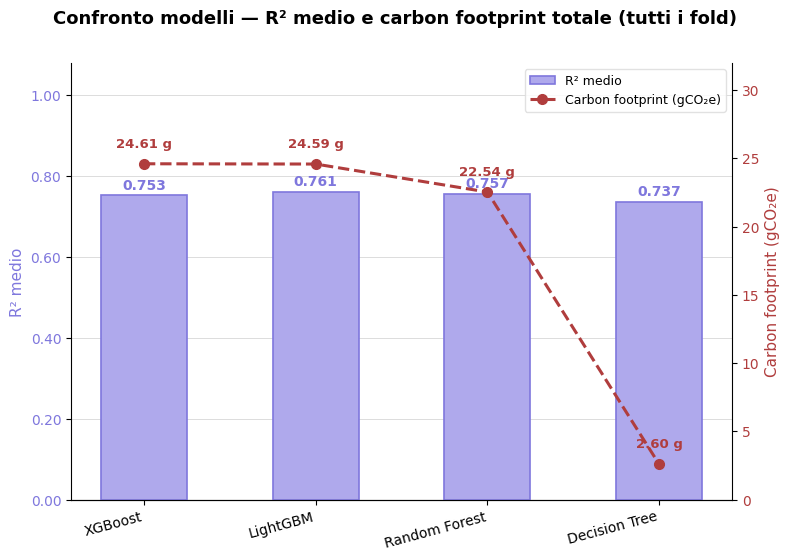

In [ ]:
# ─────────────────────────────────────────────────────────────────
# CARICAMENTO DATI
# ─────────────────────────────────────────────────────────────────

summaries = {
    "XGBoost":       pd.read_csv("XGBoost_summary.csv"),
    "LightGBM":      pd.read_csv("LGBM_summary.csv"),
    "Random Forest": pd.read_csv("RF_summary.csv"),
    "Decision Tree": pd.read_csv("DT_summary.csv"),
}

emissions = pd.read_csv("emissioni_modelli.csv")
emissions.columns = emissions.columns.str.strip()
emissions["modello"] = emissions["modello"].str.strip()
emissions["fold"] = emissions["fold"].astype(str).str.strip()

models = list(summaries.keys())

FOLDS = [
    "Fold 1 — test invernale (nov–dic)",
    "Fold 2 — test estivo (giu–lug)",
    "Fold 3 — test primaverile (apr–mag)",
]

# ─────────────────────────────────────────────────────────────────
# PALETTE
# ─────────────────────────────────────────────────────────────────

BAR_COLOR  = "#AFA9EC"
BAR_EDGE   = "#7F77DD"
CO2_COLOR  = "#B03D3D"

# ─────────────────────────────────────────────────────────────────
# DATI AGGREGATI (tutti i fold insieme)
# ─────────────────────────────────────────────────────────────────

# R² medio su tutti i fold, per modello
r2_means = [
    summaries[m][summaries[m]["fold"].isin(FOLDS)]["test_r2"].mean()
    for m in models
]

# Carbon footprint totale (riga "all" del csv), per modello
co2_values = [
    emissions[(emissions["modello"] == m) & (emissions["fold"] == "all")]["carbon_footprint (gCO2e)"].values[0]
    if len(emissions[(emissions["modello"] == m) & (emissions["fold"] == "all")]) > 0 else np.nan
    for m in models
]

# ─────────────────────────────────────────────────────────────────
# FIGURA: un unico pannello
# ─────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")

x         = np.arange(len(models))
bar_width = 0.5

fig.suptitle(
    "Confronto modelli: R² medio e carbon footprint totale (tutti i fold)",
    fontsize=13, fontweight="bold", y=1.01,
)

# ── Barre R² (asse sinistro) ──────────────────────────────────
bars = ax1.bar(
    x, r2_means,
    width=bar_width,
    color=BAR_COLOR,
    edgecolor=BAR_EDGE,
    linewidth=1.2,
    zorder=3,
    label="R² medio",
)

for bar, val in zip(bars, r2_means):
    if not np.isnan(val):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{val:.3f}",
            ha="center", va="bottom",
            fontsize=10, color=BAR_EDGE, fontweight="bold",
        )

ax1.set_ylim(0, 1.08)
ax1.set_ylabel("R² medio", color=BAR_EDGE, fontsize=11)
ax1.tick_params(axis="y", labelcolor=BAR_EDGE)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=10, rotation=15, ha="right")
ax1.grid(axis="y", color="gainsboro", linewidth=0.7, zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

# ── Linea carbon footprint (asse destro) ─────────────────────
ax2 = ax1.twinx()
ax2.plot(
    x, co2_values,
    color=CO2_COLOR,
    linewidth=2.2,
    linestyle="--",
    marker="o",
    markersize=7,
    zorder=4,
    label="Carbon footprint (gCO₂e)",
)

for xi, val in zip(x, co2_values):
    if not np.isnan(val):
        ax2.text(
            xi, val + (max(co2_values) * 0.04),
            f"{val:.2f} g",
            ha="center", va="bottom",
            fontsize=9.5, color=CO2_COLOR, fontweight="bold",
        )

ax2.set_ylabel("Carbon footprint (gCO₂e)", color=CO2_COLOR, fontsize=11)
ax2.tick_params(axis="y", labelcolor=CO2_COLOR)
ax2.set_ylim(bottom=0, top=max(co2_values) * 1.3)
ax2.spines[["top", "left"]].set_visible(False)

# ── Legenda ───────────────────────────────────────────────────
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right",
    fontsize=9,
    framealpha=0.85,
    edgecolor="gainsboro",
)

plt.tight_layout()
plt.show()